# 04_02: Loading station data

In [1]:
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp

    IV. FORMAT OF "ghcnd-stations.txt"

    ------------------------------
    Variable   Columns   Type
    ------------------------------
    ID            1-11   Character
    LATITUDE     13-20   Real
    LONGITUDE    22-30   Real
    ELEVATION    32-37   Real
    STATE        39-40   Character
    NAME         42-71   Character
    GSN FLAG     73-75   Character
    HCN/CRN FLAG 77-79   Character
    WMO ID       81-85   Character
    ------------------------------


In [3]:
stations = np.genfromtxt('ghcnd-stations.txt', 
                         delimiter=[11,9,10,7,3,31,4,4,6],
                         names=['id','latitude','longitude','elevation','state','name','gsn','hcn','wmo'],
                         dtype=['U11','d','d','d','U3','U31','U4','U4','U6'],
                         autostrip=True)

In [4]:
len(stations)

127994

In [5]:
stations

array([('ACW00011604',  17.1167, -61.7833,   10.1, '', 'ST JOHNS COOLIDGE FLD', '', '', ''),
       ('ACW00011647',  17.1333, -61.7833,   19.2, '', 'ST JOHNS', '', '', ''),
       ('AE000041196',  25.333 ,  55.517 ,   34. , '', 'SHARJAH INTER. AIRP', 'GSN', '', '41196'),
       ...,
       ('ZI000067977', -21.017 ,  31.583 ,  430. , '', 'BUFFALO RANGE', '', '', '67977'),
       ('ZI000067983', -20.2   ,  32.616 , 1132. , '', 'CHIPINGE', 'GSN', '', '67983'),
       ('ZI000067991', -22.217 ,  30.    ,  457. , '', 'BEITBRIDGE', '', '', '67991')],
      shape=(127994,), dtype=[('id', '<U11'), ('latitude', '<f8'), ('longitude', '<f8'), ('elevation', '<f8'), ('state', '<U3'), ('name', '<U31'), ('gsn', '<U4'), ('hcn', '<U4'), ('wmo', '<U6')])

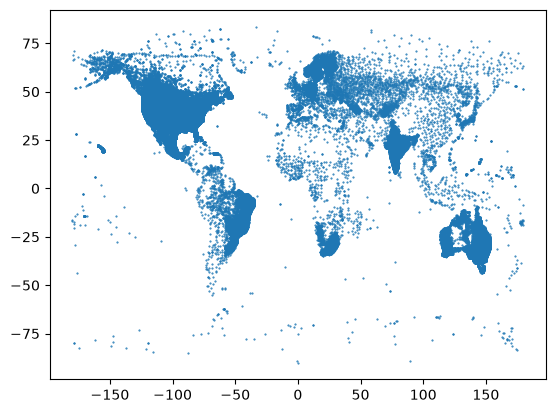

In [6]:
pp.plot(stations['longitude'], stations['latitude'], '.', markersize=1)

In [7]:
stations_ca = stations[stations['state'] == 'CA']

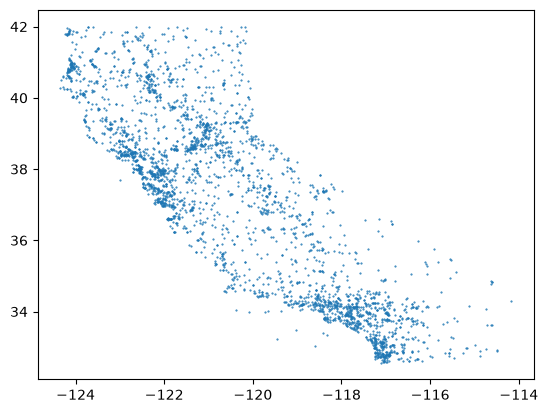

In [8]:
pp.plot(stations_ca['longitude'], stations_ca['latitude'], '.', markersize=1)

In [11]:
stations_ia =stations[stations['state'] == 'IA'] 
stations_ia

array([('US1IAAL0003', 43.1899, -91.3536, 372.2, 'IA', 'MONONA 9.8 N', '', '', ''),
       ('US1IAAL0004', 43.2673, -91.4669, 383.4, 'IA', 'WAUKON 0.5 ESE', '', '', ''),
       ('US1IAAL0005', 43.4017, -91.2851, 341.4, 'IA', 'LANSING 4.1 NW', '', '', ''),
       ...,
       ('USW00094988', 42.1106, -92.9164, 295.4, 'IA', 'MARSHALLTOWN MUNI AP', '', '', ''),
       ('USW00094989', 41.9906, -93.6186, 281.3, 'IA', 'AMES MUNI AP', '', '', ''),
       ('USW00094991', 40.6306, -93.9006, 345.6, 'IA', 'LAMONI MUNI AP', '', '', '')],
      shape=(1070,), dtype=[('id', '<U11'), ('latitude', '<f8'), ('longitude', '<f8'), ('elevation', '<f8'), ('state', '<U3'), ('name', '<U31'), ('gsn', '<U4'), ('hcn', '<U4'), ('wmo', '<U6')])

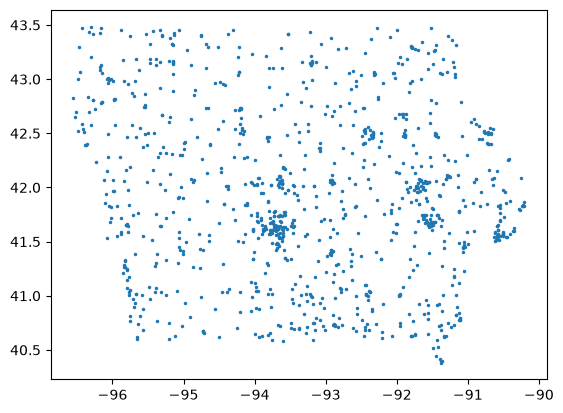

In [13]:
pp.plot(stations_ia['longitude'], stations_ia['latitude'], '.', markersize=3)

In [14]:
stations[stations['name'] == 'PASADENA']

array([('USC00046719', 34.1483, -118.1447, 263.3, 'CA', 'PASADENA', '', 'HCN', '')],
      dtype=[('id', '<U11'), ('latitude', '<f8'), ('longitude', '<f8'), ('elevation', '<f8'), ('state', '<U3'), ('name', '<U31'), ('gsn', '<U4'), ('hcn', '<U4'), ('wmo', '<U6')])

In [15]:
stations[np.char.startswith(stations['name'], 'PASADENA')]

array([('CA1NL000026', 49.0094,  -57.5849,  52.4, 'NL', 'PASADENA 0.5 SE', '', '', ''),
       ('US1CALA0036', 34.1392, -118.1161, 225.2, 'CA', 'PASADENA 2.0 SE', '', '', ''),
       ('US1CALA0043', 34.1619, -118.1073, 277.7, 'CA', 'PASADENA 1.8 E', '', '', ''),
       ('US1CALA0091', 34.1648, -118.1249, 289. , 'CA', 'PASADENA 0.8 ENE', '', '', ''),
       ('US1CALA0124', 34.1336, -118.1416, 234.1, 'CA', 'PASADENA 1.9 S', '', '', ''),
       ('US1MDAA0010', 39.1038,  -76.5443,  13.1, 'MD', 'PASADENA 0.7 SE', '', '', ''),
       ('US1MDAA0013', 39.1263,  -76.5596,  18.9, 'MD', 'PASADENA 1.1 NNW', '', '', ''),
       ('US1MDAA0039', 39.0916,  -76.5112,  10.7, 'MD', 'PASADENA 2.6 ESE', '', '', ''),
       ('US1TXHRR076', 29.6471,  -95.1895,  10.7, 'TX', 'PASADENA 2.4 WSW', '', '', ''),
       ('US1TXHRR084', 29.6339,  -95.1881,  11.9, 'TX', 'PASADENA 2.8 SW', '', '', ''),
       ('US1TXHRR093', 29.6849,  -95.2197,   9.1, 'TX', 'PASADENA 4.4 WNW', '', '', ''),
       ('US1TXHRR094', 29.674

In [16]:
open('PASADENA.dly', 'r').readlines()[:10]

['USC00046719189301TMAX  244  6  272  6  278  6  267  6  272  6  233  6  250  6  267  6  250  6  194  6  156  6  244  6  228  6  200  6  206  6  156  6  144  6  200  6  233  6  206  6  244  6  239  6  261  6  261  6  211  6  111  6  144  6  156  6  139  6  122  6  144  6\n',
 'USC00046719189301TMIN   61  6   78  6   78  6   94  6   67  6   50  6   33  6   78  6   50  6   39  6   33  6   56  6   78  6   50  6   94  6   72  6   28  6   17  6   44  6   61  6   50  6   61  6   78  6   61  6   44  6   28  6   89  6   56  6   61  6  100  6   94  6\n',
 'USC00046719189301PRCP    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    8  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6   64  6  478  6    3  6    5  6  798  6  559  6\n',
 'USC00046719189301SNOW    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0  6    0

In [17]:
import getweather

In [18]:
help(getweather.getyear)

Help on function getyear in module getweather:

getyear(station_name, elements, year)
    Make a NumPy record array of length 365, containing weather data
    at station_name for the list of requested elements (TMIN/TMAX/PRCP/SNOW),
    restricted to year.

    If station_name is not in the list, find a station that _begins_
    with station_name, but give precedence to HCN and GSN stations.



In [20]:
getweather.getyear('PASADENA', ['TMIN','TMAX', 'SNOW'], 2000)

array([( 6.1, 14.4,  0.), ( 6.1, 18.3,  0.), ( 3.9, 18.3,  0.),
       ( 6.1, 20. ,  0.), ( 6.1, 20.6,  0.), ( 5.6, 20. ,  0.),
       ( 5.6, 18.3,  0.), ( 3.3, 21.7,  0.), ( 5. , 20.6,  0.),
       ( 6.1, 18.3,  0.), ( 6.7, 18.9,  0.), ( 8.3, 17.8,  0.),
       ( 7.8, 24.4,  0.), (11.1, 26.1,  0.), (12.8, 26.1,  0.),
       (13.3, 23.9,  0.), (13.3, 20.6,  0.), (13.9, 24.4,  0.),
       (11.1, 25.6,  0.), (12.8, 21.7,  0.), (11.7, 18.3,  0.),
       (10. , 18.3,  0.), ( 7.8, 20. ,  0.), (11.7, 22.8,  0.),
       (12.2, 21.7,  0.), ( 8.3, 20.6,  0.), ( 7.2, 20.6,  0.),
       ( 6.1, 21.7,  0.), ( 6.7, 21.7,  0.), (10. , 17.8,  0.),
       (11.1, 16.7,  0.), (13.3, 24.4,  0.), (11.1, 26.7,  0.),
       ( 9.4, 26.7,  0.), ( 8.9, 23.9,  0.), (10.6, 21.1,  0.),
       ( 6.7, 25. ,  0.), ( nan,  nan, nan), (15.6, 26.7,  0.),
       (10. , 23.9,  0.), (10.6, 19.4,  0.), ( 5. , 18.3,  0.),
       ( 9.4, 17.8,  0.), ( 9.4, 15.6,  0.), (10.6, 16.7,  0.),
       ( 8.9, 19.4,  0.), (10. , 16.7,  